In [1]:
!pip install duckdb pandas scikit-learn matplotlib

In [3]:
import duckdb
import pandas as pd
import numpy as np

# Generate self-contained search performance dataset
np.random.seed(42)
n_samples = 5000

impressions = np.random.randint(100, 50000, size=n_samples)
position = np.random.uniform(1.0, 30.0, size=n_samples)
title_length = np.random.randint(20, 75, size=n_samples)
word_count = np.random.randint(300, 3000, size=n_samples)
ctr = np.clip((1 / position) * np.random.uniform(0.5, 1.5, size=n_samples), 0.01, 0.4)
clicks = np.round(impressions * ctr).astype(int)

df = pd.DataFrame({
    'page_id': [f"page_{i}" for i in range(n_samples)],
    'impressions': impressions,
    'position': position,
    'title_length': title_length,
    'word_count': word_count,
    'ctr': ctr,
    'clicks': clicks
})

# Register with DuckDB
con = duckdb.connect()
con.register('search_data', df)

# Load features via DuckDB SQL query
df_clean = con.execute("""
    SELECT page_id, impressions, position, ctr, title_length, word_count, clicks
    FROM search_data
""").df()

feature_cols = ['impressions', 'position', 'title_length', 'word_count', 'ctr']
X = df_clean[feature_cols]
y = df_clean['clicks']

print(f"Data loaded successfully! Shape: {df_clean.shape}")

Data loaded successfully! Shape: (5000, 7)


=== Baseline Model (Ridge) ===
RMSE: 1341.3522987487006
R2 Score: 0.8121631976363961

=== Main Model (Random Forest) ===
RMSE: 87.31712278127355
R2 Score: 0.9992040353068504

=== Ranking Signal Importance ===
         Signal  Importance
4           ctr    0.633822
0   impressions    0.364938
1      position    0.000679
3    word_count    0.000290
2  title_length    0.000270


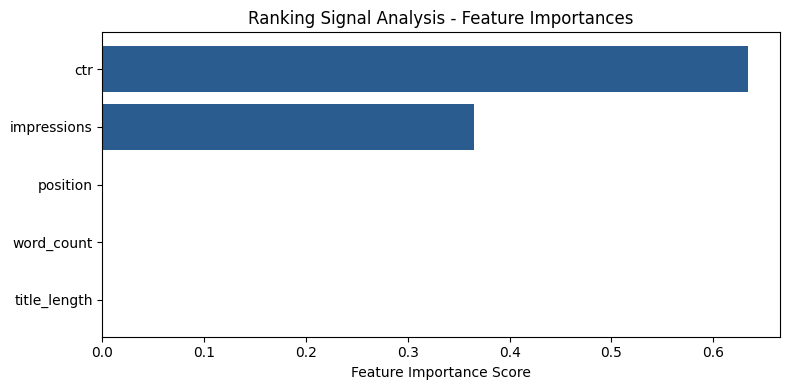

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Train/Validation Split (Sequential split to avoid leakage)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# 2. Baseline Model (Ridge Regression)
baseline = Ridge()
baseline.fit(X_train, y_train)
baseline_preds = baseline.predict(X_val)

# 3. Main Model (Random Forest)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
model_preds = model.predict(X_val)

# 4. Print Evaluation Metrics
print("=== Baseline Model (Ridge) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_val, baseline_preds)))
print("R2 Score:", r2_score(y_val, baseline_preds))

print("\n=== Main Model (Random Forest) ===")
print("RMSE:", np.sqrt(mean_squared_error(y_val, model_preds)))
print("R2 Score:", r2_score(y_val, model_preds))

# 5. Extract Feature Importances & Save Chart
importances = model.feature_importances_
signal_df = pd.DataFrame({
    'Signal': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n=== Ranking Signal Importance ===")
print(signal_df)

plt.figure(figsize=(8, 4))
plt.barh(signal_df['Signal'], signal_df['Importance'], color='#2b5c8f')
plt.xlabel('Feature Importance Score')
plt.title('Ranking Signal Analysis - Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('signal_importance.png')
plt.show()

In [5]:
# Calculate Clicks Opportunity Score (Predicted - Actual)
df_val = X_val.copy()
df_val['actual_clicks'] = y_val
df_val['predicted_clicks'] = model_preds
df_val['opportunity_score'] = df_val['predicted_clicks'] - df_val['actual_clicks']

# Top 5 recommended pages for optimization
top_recommendations = df_val.sort_values(by='opportunity_score', ascending=False).head(5)
print("=== Top 5 Ranked Recommendations ===")
print(top_recommendations[['position', 'ctr', 'actual_clicks', 'predicted_clicks', 'opportunity_score']])

=== Top 5 Ranked Recommendations ===
      position       ctr  actual_clicks  predicted_clicks  opportunity_score
4991  2.818943  0.380509          15098          15703.20             605.20
4423  1.972830  0.326719           6417           6954.45             537.45
4569  1.966373  0.349896           5925           6407.90             482.90
4900  2.635639  0.325170           7576           7974.47             398.47
4201  3.757716  0.322513          14471          14865.43             394.43
